In [10]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [11]:
#Import all the necessary modules
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt 
import seaborn as sns

In [12]:
df = pd.read_csv( 'parkinsons.data' )
# The main aim of the data is to discriminate healthy people from those with PD, according to "status" 
# column which is set to 0 for healthy and 1 for PD.
df.shape

(195, 24)

In [13]:
df.head(15)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
5,phon_R01_S01_6,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,...,0.06985,0.01222,21.378,1,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
6,phon_R01_S02_1,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,...,0.02337,0.00607,24.886,1,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
7,phon_R01_S02_2,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,...,0.02487,0.00344,26.892,1,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
8,phon_R01_S02_3,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,...,0.03218,0.01070,21.812,1,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
9,phon_R01_S02_4,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,...,0.04324,0.01022,21.862,1,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362


In [14]:
# check for Missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [15]:
# 3.	Using univariate & bivariate analysis to check the individual attributes for their basic statistic #
# such as central values, spread, tails etc. 

df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [16]:
# Check distribution against the Target Column
df.groupby(["status"]).count().T


status,0,1
name,48,147
MDVP:Fo(Hz),48,147
MDVP:Fhi(Hz),48,147
MDVP:Flo(Hz),48,147
MDVP:Jitter(%),48,147
MDVP:Jitter(Abs),48,147
MDVP:RAP,48,147
MDVP:PPQ,48,147
Jitter:DDP,48,147
MDVP:Shimmer,48,147


In [17]:
df.corr()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027,-0.076194,-0.112165,-0.076213,-0.098374,-0.073742,...,-0.094732,-0.021981,0.059144,-0.383535,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198,0.097177,0.091126,0.097150,0.002281,0.043465,...,-0.003733,0.163766,-0.024893,-0.166136,-0.112404,-0.343097,-0.076658,-0.002954,0.176323,-0.069543
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815,-0.100519,-0.095828,-0.100488,-0.144543,-0.119089,...,-0.150737,-0.108670,0.210851,-0.380200,-0.400143,-0.050406,-0.394857,-0.243829,-0.100629,-0.340071
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714,0.990276,0.974256,0.990276,0.769063,0.804289,...,0.746635,0.906959,-0.728165,0.278220,0.360673,0.098572,0.693577,0.385123,0.433434,0.721543
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000,0.922911,0.897778,0.922913,0.703322,0.716601,...,0.697170,0.834972,-0.656810,0.338653,0.441839,0.175036,0.735779,0.388543,0.310694,0.748162
MDVP:RAP,-0.076194,0.097177,-0.100519,0.990276,0.922911,1.000000,0.957317,1.000000,0.759581,0.790652,...,0.744919,0.919521,-0.721543,0.266668,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999
MDVP:PPQ,-0.112165,0.091126,-0.095828,0.974256,0.897778,0.957317,1.000000,0.957319,0.797826,0.839239,...,0.763592,0.844604,-0.731510,0.288698,0.333274,0.196301,0.716489,0.407605,0.412524,0.769647
Jitter:DDP,-0.076213,0.097150,-0.100488,0.990276,0.922913,1.000000,0.957319,1.000000,0.759555,0.790621,...,0.744901,0.919548,-0.721494,0.266646,0.342079,0.064026,0.648328,0.324377,0.426556,0.671005
MDVP:Shimmer,-0.098374,0.002281,-0.144543,0.769063,0.703322,0.759581,0.797826,0.759555,1.000000,0.987258,...,0.987626,0.722194,-0.835271,0.367430,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771
MDVP:Shimmer(dB),-0.073742,0.043465,-0.119089,0.804289,0.716601,0.790652,0.839239,0.790621,0.987258,1.000000,...,0.963202,0.744477,-0.827805,0.350697,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058


In [18]:
# MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Several measures of variation in fundamental frequency
# Check for co-relation between these variables
df[['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP','MDVP:PPQ','Jitter:DDP']].corr()['Jitter:DDP'][:]

MDVP:Jitter(%)      0.990276
MDVP:Jitter(Abs)    0.922913
MDVP:RAP            1.000000
MDVP:PPQ            0.957319
Jitter:DDP          1.000000
Name: Jitter:DDP, dtype: float64

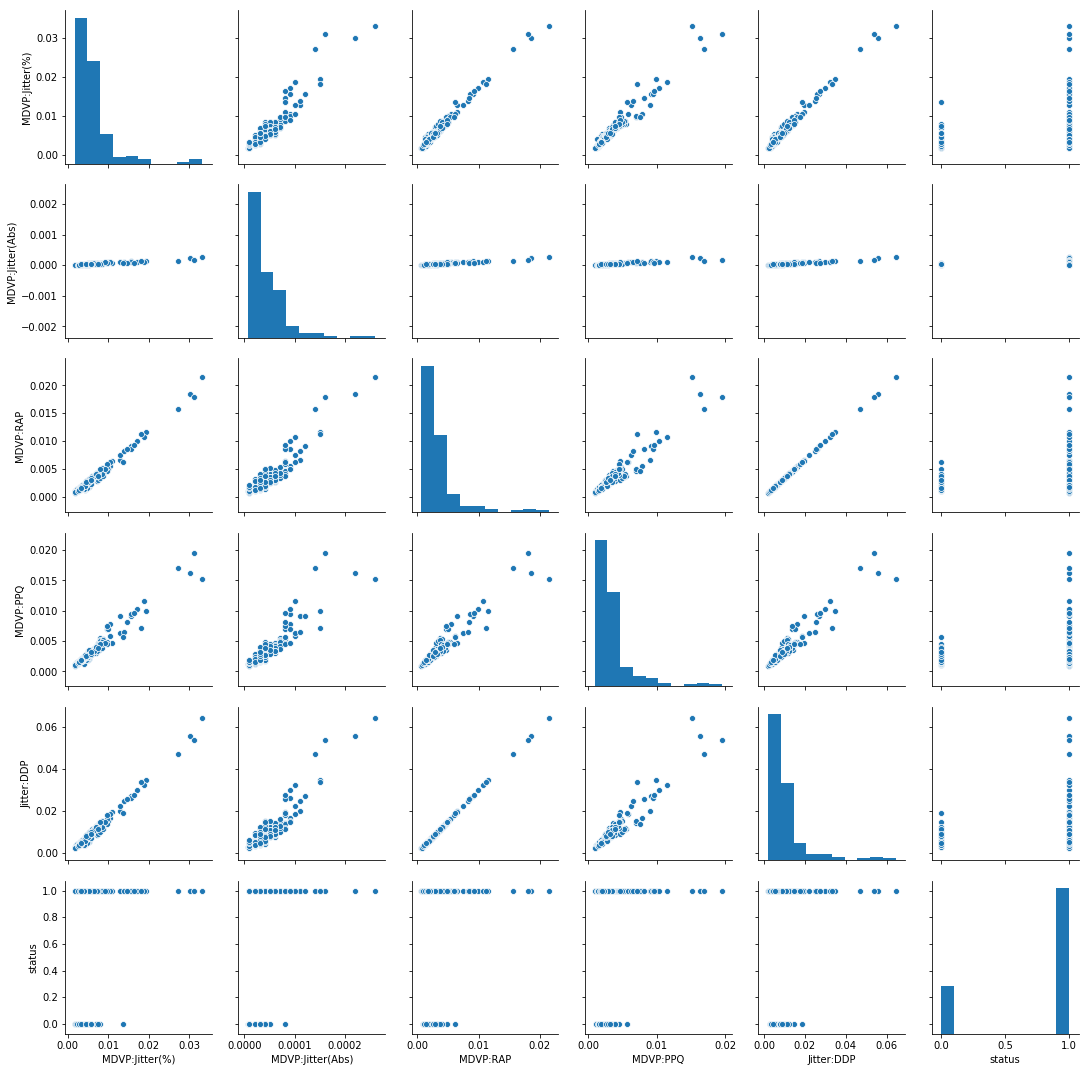

In [19]:
sns.pairplot(df[['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP','MDVP:PPQ','Jitter:DDP','status']])

In [20]:
# MDVP:Shimmer,MDVP:Shimmer(dB),MDVP:Shimmer(dB),Shimmer:APQ5,MDVP:APQ,Shimmer:DDA - Several measures of variation in amplitude
# Check for co-relation between these variables
df[['MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ5','MDVP:APQ','Shimmer:DDA']].corr()['Shimmer:DDA'][:]

MDVP:Shimmer        0.987626
MDVP:Shimmer(dB)    0.963202
Shimmer:APQ5        0.960072
MDVP:APQ            0.896647
Shimmer:DDA         1.000000
Name: Shimmer:DDA, dtype: float64

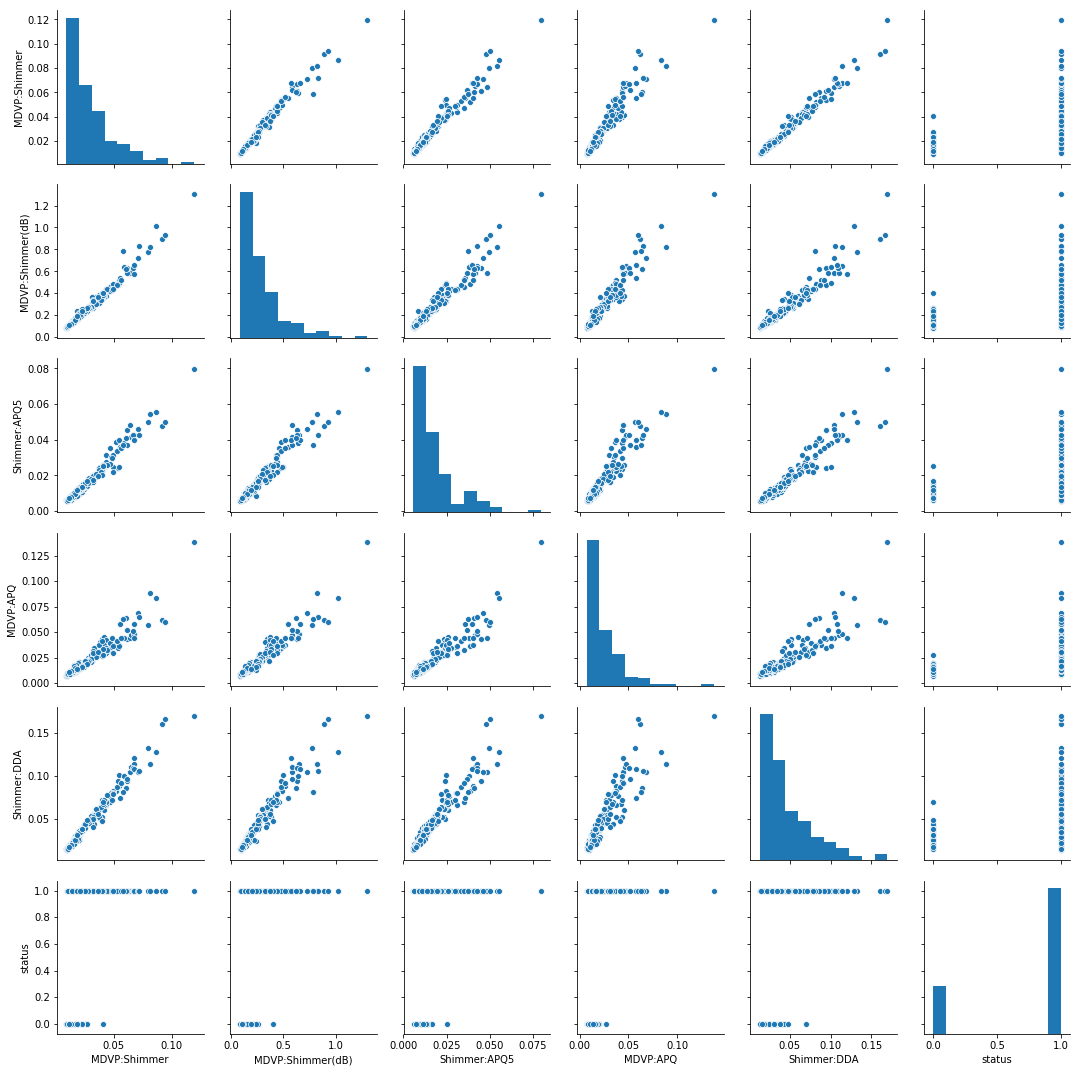

In [21]:
sns.pairplot(df[['MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ5','MDVP:APQ','Shimmer:DDA','status']])


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x00000215AD206710>,
      dtype=object)

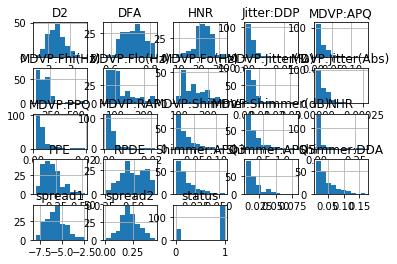

In [22]:
# Plot the distribution of target variable using histogram
df.hist()

In [23]:
# Observations :
# - The dataset consists of 195 rows and 24 attributes
# - There are no Missing Datapoints
# - Target variable is 'status' - based on the data Healthy is 0 and Diseased is 1
# - The given Dataset has more values of Diseased rows ( status = 1 ), than Healthy - 75% of the data given falls under Diseased
# - Most of the attributes are continuous variables, there are no Categorical variable in the Input Attributes
# - Some of the attributes are highly co-related - ex - MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP 
#   AND MDVP:Shimmer,MDVP:Shimmer(dB),MDVP:Shimmer(dB),Shimmer:APQ5,MDVP:APQ,Shimmer:DDA
# - name attribute will not impact the model and can be dropped
# - There is high variation in the ranges in attributes is - recommended for Feature Scaling

In [24]:
#Drop Id variable from data
if 'name' in df:
    df.drop("name", axis=1, inplace = True)

In [25]:
# Prepare X and Y
X = df.drop("status", axis=1)
y = df["status"]

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_std=sc.fit_transform(X)
X_std[0:5]

array([[-0.82929965, -0.43616456, -0.95203729,  0.33491386,  0.74975946,
         0.13296255,  0.76080023,  0.13175532,  0.74598495,  0.73953578,
         0.60785907,  1.11914677,  0.33298451,  0.60753214, -0.06789281,
        -0.19322537, -0.8078385 ,  1.76081412,  0.80132308,  0.48047686,
        -0.21053082,  0.86888575],
       [-0.77097169, -0.53097409, -0.05772056,  0.71541825,  1.03767418,
         0.45389169,  1.27680862,  0.45268371,  1.68173116,  1.7684643 ,
         1.54791153,  2.27650439,  1.15945391,  1.54825419, -0.13784252,
        -0.63450828, -0.38752443,  1.83756192,  1.47985265,  1.31118546,
         0.27507712,  1.80360503],
       [-0.90947638, -0.7231683 , -0.10987483,  0.88499086,  1.3255889 ,
         0.72076961,  1.58568688,  0.72181312,  1.2026929 ,  1.02763576,
         1.17564285,  1.72617584,  0.69918677,  1.17532274, -0.29163266,
        -0.27976031, -0.66207509,  1.94204837,  1.14144541,  1.01768236,
        -0.10362861,  1.40266141],
       [-0.90962172

In [26]:
# 4.	Split the dataset into training and test set in the ratio of 70:30 (Training:Test).

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size = 0.3, random_state = 7)

In [28]:
# 5.	Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)

In [111]:
from sklearn.tree import DecisionTreeClassifier

DT_model = DecisionTreeClassifier(criterion='entropy',random_state=7)
DT_model.fit(X_train, y_train)


DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=7,
            splitter='best')

In [31]:
#6.Test the model on test data and what is the accuracy achieved. 
# Capture the predicted values and do a crosstab. (7.5 points)

In [112]:
test_accuracy = accuracy_score(y_test, DT_model.predict(X_test))
print("Decision Tree Classifier got {}% accuracy on the test set.".format((test_accuracy)*100))
print(" ")
# Capture the predicted values
yPred = DT_model.predict(X_test)
metrics.confusion_matrix(y_test,yPred)

print("CrossTab - Confusion Matrix")
print(pd.crosstab(y_test, yPred))

print("CrossTab - Classification Report")
print(metrics.classification_report(y_test,yPred))

Decision Tree Classifier got 88.13559322033898% accuracy on the test set.
 
CrossTab - Confusion Matrix
col_0   0   1
status       
0       9   3
1       4  43
CrossTab - Classification Report
              precision    recall  f1-score   support

           0       0.69      0.75      0.72        12
           1       0.93      0.91      0.92        47

   micro avg       0.88      0.88      0.88        59
   macro avg       0.81      0.83      0.82        59
weighted avg       0.89      0.88      0.88        59



In [ ]:
# 7.	Use regularization parameters of max_depth, min_sample_leaf to recreate the model. 
# What is the impact on the model accuracy? How does regularization help?

In [121]:
# Find Optimal max_depth parameter
max_depths = np.linspace(1, 32, 32, endpoint=True)
acc_list = []
for max_depth in max_depths :
        model = DecisionTreeClassifier(criterion='entropy',max_depth = max_depth,random_state=7)
        model.fit(X_train, y_train)
        YPreds = model.predict(X_train)
        acc_list.append(accuracy_score(y_train, YPreds))

# Find Optimal max_depth based on Highest accuracy
OPTIMAL_DEPTH = max_depths[acc_list.index(max(acc_list))]
print("The optimal max_depth parameter is",OPTIMAL_DEPTH)

The optimal max_depth parameter is 5.0


In [122]:
# Find Optimal min_sample_leaf parameter
min_leafs = np.linspace(0.01, 0.5, 15, endpoint=True)
acc_list = []
for min_leaf in min_leafs :
        model = DecisionTreeClassifier(criterion='entropy',max_depth = OPTIMAL_DEPTH,min_samples_leaf = min_leaf, random_state=7)
        model.fit(X_train, y_train)
        YPreds = model.predict(X_train)
        acc_list.append(accuracy_score(y_train, YPreds))

# Find Optimal max_depth based on Highest F1 Score
OPTIMAL_LEAF = min_leafs[acc_list.index(max(acc_list))]
print("The optimal min_sample_leaf parameter is",OPTIMAL_LEAF)

The optimal min_sample_leaf parameter is 0.01


In [129]:
# Recreate Model using OPTIMAL_DEPTH and OPTIMAL_LEAF parameter
model = DecisionTreeClassifier(criterion='entropy',max_depth = OPTIMAL_DEPTH,min_samples_leaf = OPTIMAL_LEAF,random_state=7)
model.fit(X_train, y_train)

test_accuracy = accuracy_score(y_test, model.predict(X_test))
print("Decision Tree Classifier got {}% accuracy on the test set.".format((test_accuracy)*100))

Decision Tree Classifier got 88.13559322033898% accuracy on the test set.


In [135]:
# Alternatively we can use GridSearch to get the best params
# Perform Grid Search Method to find the optimal max_depth and min_samples_leaf size
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.linspace(1, 32, 32, endpoint=True),'min_samples_leaf':np.linspace(0.01, 0.5, 15, endpoint=True)}
GS=GridSearchCV(model,parameter,cv=3)
# cv = 3 => 3 fold cross validation
GS.fit(X_train,y_train)
print(GS.best_params_)
gs_pred=GS.predict(X_test)
print("Accuracy with Optimal Grid Search Parameters {}% .".format(metrics.accuracy_score(y_test,gs_pred)*100))

{'max_depth': 2.0, 'min_samples_leaf': 0.185}
Accuracy with Optimal Grid Search Parameters 84.7457627118644% .


C:\Users\Suchi\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


In [ ]:
# How does regularization help ?
# - If we set max_depth too high, then the decision tree might overfit the training data, resulting in poor test results
# - Regularization using max_depth causes the accuracy in test results to increase by ensuring that the model is optimally fit using training data
# - min_samples_leaf is the minimum number of samples required to be at a leaf node. 
# - Regularization using min_samples_leaf ensures optimation. 
# - A higher min_samples_leaf will cause a underfit model where as a very low min_samples_leaf will result in overfit 
# - In the case above the changes in accuracy score after regularization is not so evident because the no. of samples is very less < 200 

In [ ]:
# 8.	Next implement the decision tree using Random Forest. 

In [152]:
from sklearn.ensemble import RandomForestClassifier

#Bootstrapped sampled multiple decision tree
Rf_model = RandomForestClassifier(n_estimators=45,criterion='entropy',random_state=0 )
Rf_model.fit(X_train, y_train)

test_accuracy = accuracy_score(y_test, Rf_model.predict(X_test))
print("Random Forest Classifier got {}% accuracy on the test set.".format((test_accuracy)*100))

Random Forest Classifier got 89.83050847457628% accuracy on the test set.


In [155]:
parameter={'n_estimators':np.arange(1,101)}
GS=GridSearchCV(Rf_model,parameter,cv=3)
# cv = 3 => 3 fold cross validation
GS.fit(X_train,y_train)
print(GS.best_params_)
gs_pred=GS.predict(X_test)
print("Accuracy with Optimal Grid Search Parameters {}% .".format(metrics.accuracy_score(y_test,gs_pred)*100))

{'n_estimators': 50}
Accuracy with Optimal Grid Search Parameters 89.83050847457628% .


C:\Users\Suchi\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


In [ ]:
# What is the optimal number of trees that gives the best result? 
# - The Optimal No. of Trees that gives best result is between 45 to 51